# model_3_20_fast.ipynb — BinAvgFit + FullDiscrete 建模

**方法**：BinAvgFit + FullDiscrete（任务书 §10 最终方案），取代旧版的 ExpWindow FFTLog 方法。

**运行环境**：`conda activate desilike`

## 代码各部分说明

```
Cell 1  参数区        — 所有可调路径、盒长、拟合设置集中在此
Cell 2  辅助函数定义  — parse_rid / load_pk_ensemble / load_pcf_ensemble
Cell 3  读取 P(k)     — 批量读取 pk_rsd_N*.dat，画均值谱
Cell 4  pypower 对象  — 把 data/cov mocks 封装成 desilike 可识别格式
Cell 5  标准拟合      — desilike + MinuitProfiler，bin center 口径（作为 BinAvgFit 初始值）
Cell 6  BinAvgFit     — 用离散模式加权 bin-average 理论重新做 χ² 拟合（核心改进）
                        得到 bf_binavg：消除了 bin-center vs bin-average 不自洽
Cell 7  P(k) 对比图   — 画数据均值 vs BinAvgFit / 标准拟合曲线（图1）
Cell 8  FullDiscrete  — 离散壳层求和建模 ξ0(r)（k-rebinning 加速版）
                        原理：壳层按 k 值聚合到 bin，加速 500-800x
Cell 9  读取 2PCF     — 批量读取 pcf_rsd_N*.dat，得到观测均值与误差
Cell 10 对比与画图    — r²ξ0(r) 对比图（图2）+ (Data-Model)/σ 残差图（图3）
Cell 11 指标输出      — mean(|Δ/σ|) 和 mean(Δ/σ) 数值汇总
```

In [1]:
# ============================================================
# Cell 1：参数区（所有可调项统一放在这里，运行前只需改这里）
# ============================================================

import os, re, glob, time
import numpy as np
import matplotlib.pyplot as plt

# ---------- 数据路径 ----------
# 功率谱 data（用于拟合）
DATA_DIR  = '/pscratch/sd/l/lzy/3gpc-UNIT-fastpm/pk_masscut'
FILE_GLOB = 'pk_rsd_3gpc_fnl100_N*.dat'

# 功率谱 covariance（允许与 data 的 fnl 不同，例如用 fnl0 估计协方差）
COV_DIR  = '/pscratch/sd/l/lzy/3gpc-UNIT-fastpm/pk_masscut'
COV_GLOB = 'pk_rsd_3gpc_fnl0_N*.dat'

# 2PCF 数据
PCF_DIR  = '/pscratch/sd/l/lzy/3gpc-UNIT-fastpm/pcf_masscut'
PCF_GLOB = 'pcf_rsd_3gpc_fnl100_N*.dat'

# ---------- realization 范围 ----------
REALIZATION_MIN = 2
REALIZATION_MAX = 99

# ---------- 盒长相关 ----------
BOX_SIZE = 3000.0                       # Mpc/h
K_FUND   = 2.0 * np.pi / BOX_SIZE      # 基模 k_f = 2π/L  (h/Mpc)
VOL      = BOX_SIZE ** 3               # 体积 L^3  (Mpc/h)^3

# ---------- 拟合设置 ----------
N_DATAPOINTS = 20      # 拟合使用的 k-bin 数量（前 N_DATAPOINTS 个 bin）
FIXED_P      = 1.2     # PNG bias 参数 p，固定不拟合
FIXED_SN0    = 0.0     # 散粒噪声 sn0，固定为 0
UNIT_Z       = 1.0     # 有效红移
MINUIT_SEED  = 66
MINUIT_NITER = 27

# ---------- FullDiscrete 离散求和设置 ----------
KMAX_DISCRETE = 15.0      # 离散求和截断 (h/Mpc)；任务书 §9 要求 kmax >= 15
N_DENSE       = 300_000   # 密集 k 网格点数，用于 P_model(k) 插值

# ---------- pk 文件列索引 ----------
K_CEN_COL = 0
K_MIN_COL = 1
K_MAX_COL = 2
P0_COL    = 5

print('参数加载完成。')
print(f'  DATA_DIR     = {DATA_DIR}')
print(f'  FILE_GLOB    = {FILE_GLOB}')
print(f'  realization 范围 = [{REALIZATION_MIN}, {REALIZATION_MAX}]')
print(f'  N_DATAPOINTS = {N_DATAPOINTS}')
print(f'  BOX_SIZE = {BOX_SIZE} Mpc/h,  K_FUND = {K_FUND:.6f} h/Mpc')
print(f'  KMAX_DISCRETE = {KMAX_DISCRETE} h/Mpc')

参数加载完成。
  DATA_DIR     = /pscratch/sd/l/lzy/3gpc-UNIT-fastpm/pk_masscut
  FILE_GLOB    = pk_rsd_3gpc_fnl100_N*.dat
  realization 范围 = [2, 99]
  N_DATAPOINTS = 20
  BOX_SIZE = 3000.0 Mpc/h,  K_FUND = 0.002094 h/Mpc
  KMAX_DISCRETE = 15.0 h/Mpc


In [2]:
# ============================================================
# Cell 2：辅助函数定义
# ============================================================

def parse_realization_id(filepath):
    """
    从文件名提取 realization 编号（格式：...N{id}...）。

    参数
    ----
    filepath : str  文件路径。

    返回
    ----
    int  编号；若解析失败返回 -1。
    """
    name  = os.path.basename(filepath)
    match = re.search(r'N(\d+)', name)
    return int(match.group(1)) if match else -1


def load_pk_ensemble(data_dir, file_glob, rid_min, rid_max, n_dp,
                     k_cen_col=0, k_min_col=1, k_max_col=2, p0_col=5):
    """
    批量读取功率谱 realization 文件，返回 k 网格与 mock 矩阵。

    参数
    ----
    data_dir, file_glob : str
        文件目录与 glob 模式（如 'pk_rsd_N*.dat'）。
    rid_min, rid_max : int
        realization 编号范围（闭区间）。
    n_dp : int
        截取前多少个 k-bin。
    k_cen_col, k_min_col, k_max_col, p0_col : int
        文件各列对应的列索引。

    返回
    ----
    dict，含：
        kcen  : ndarray (n_dp,)         — k-bin 中心
        kmin  : ndarray (n_dp,)         — k-bin 下边界
        kmax  : ndarray (n_dp,)         — k-bin 上边界
        mocks : ndarray (n_mock, n_dp)  — 各 realization 的 P0
        mean  : ndarray (n_dp,)         — mock 均值
        std   : ndarray (n_dp,)         — mock 标准差（ddof=1）
    """
    pattern  = os.path.join(data_dir, file_glob)
    all_fps  = sorted(glob.glob(pattern), key=parse_realization_id)
    fps      = [f for f in all_fps
                if rid_min <= parse_realization_id(f) <= rid_max]
    if not fps:
        raise FileNotFoundError(
            f'未找到文件：{pattern}，realization 范围 [{rid_min}, {rid_max}]')

    ref  = np.loadtxt(fps[0], comments='#')
    kcen = ref[:n_dp, k_cen_col].copy()
    kmin = ref[:n_dp, k_min_col].copy()
    kmax = ref[:n_dp, k_max_col].copy()

    mocks = np.array(
        [np.loadtxt(f, comments='#')[:n_dp, p0_col] for f in fps],
        dtype=float
    )
    return dict(kcen=kcen, kmin=kmin, kmax=kmax,
                mocks=mocks, mean=mocks.mean(axis=0),
                std=mocks.std(axis=0, ddof=1))


def load_pcf_ensemble(pcf_dir, pcf_glob, rid_min, rid_max, xi_col=3):
    """
    批量读取 2PCF 文件，返回 s 网格与 ξ0 的均值、标准差。

    参数
    ----
    pcf_dir, pcf_glob : str
        2PCF 文件目录与 glob 模式。
    rid_min, rid_max : int
        realization 范围（闭区间）。
    xi_col : int
        ξ0 所在列（默认 3）。

    返回
    ----
    s_data  : ndarray  r 网格 (Mpc/h)
    xi_mean : ndarray  ξ0 均值
    xi_std  : ndarray  ξ0 标准差（ddof=1）
    """
    pattern = os.path.join(pcf_dir, pcf_glob)
    all_fps = sorted(glob.glob(pattern), key=parse_realization_id)
    fps     = [f for f in all_fps
               if rid_min <= parse_realization_id(f) <= rid_max]
    if not fps:
        raise FileNotFoundError(f'未找到 2PCF 文件：{pattern}')

    s_data = np.loadtxt(fps[0], comments='#')[:, 0]
    mocks  = np.array(
        [np.loadtxt(f, comments='#')[:, xi_col] for f in fps],
        dtype=float
    )
    return s_data, mocks.mean(axis=0), mocks.std(axis=0, ddof=1)


print('辅助函数定义完成。')

辅助函数定义完成。


读取 data P(k)...
  mock 数量 = 98
  k 范围 = [0.00350, 0.06050] h/Mpc
读取 covariance P(k)...
  covariance mock 数量 = 98


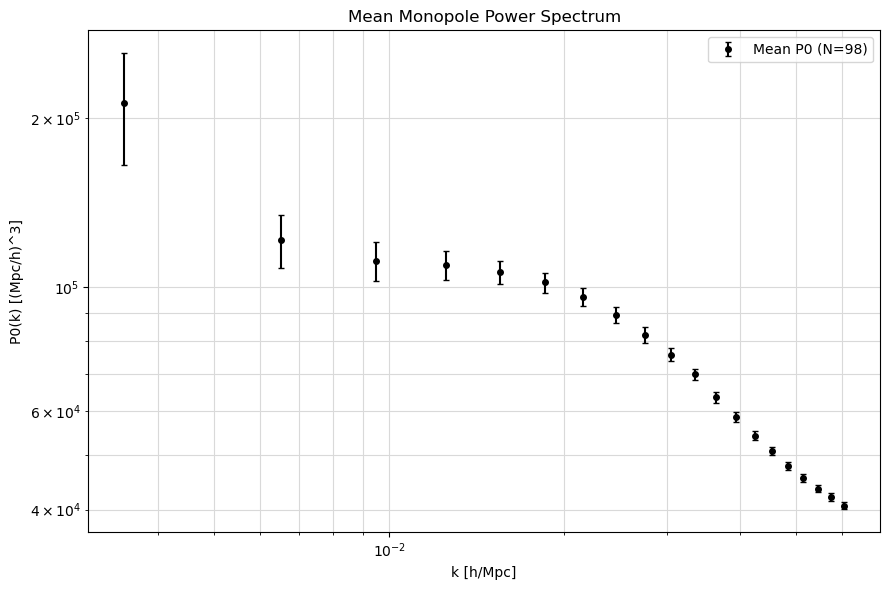

In [3]:
# ============================================================
# Cell 3：读取功率谱数据，画均值谱
# ============================================================

print('读取 data P(k)...')
pk_data = load_pk_ensemble(
    DATA_DIR, FILE_GLOB, REALIZATION_MIN, REALIZATION_MAX, N_DATAPOINTS,
    K_CEN_COL, K_MIN_COL, K_MAX_COL, P0_COL
)
print(f'  mock 数量 = {pk_data["mocks"].shape[0]}')
print(f'  k 范围 = [{pk_data["kcen"].min():.5f}, {pk_data["kcen"].max():.5f}] h/Mpc')

print('读取 covariance P(k)...')
pk_cov = load_pk_ensemble(
    COV_DIR, COV_GLOB, REALIZATION_MIN, REALIZATION_MAX, N_DATAPOINTS,
    K_CEN_COL, K_MIN_COL, K_MAX_COL, P0_COL
)
print(f'  covariance mock 数量 = {pk_cov["mocks"].shape[0]}')

# 取出后续步骤常用的变量
k_values  = pk_data['kcen']    # k-bin 中心
kmins     = pk_data['kmin']    # k-bin 下边界
kmaxs     = pk_data['kmax']    # k-bin 上边界
p0_mean   = pk_data['mean']    # 测量 P0 均值（作为拟合 data）
p0_mocks  = pk_data['mocks']   # 各 realization 的 P0（用于误差棒）
cov_mocks = pk_cov['mocks']    # 协方差估计用的 mock 矩阵

# 画均值功率谱，直观检查数据
plt.figure(figsize=(9, 6))
plt.errorbar(k_values, p0_mean, yerr=pk_data['std'],
             fmt='o', ms=4, capsize=2, color='black',
             label=f'Mean P0 (N={p0_mocks.shape[0]})')
plt.xscale('log'); plt.yscale('log')
plt.grid(True, which='both', ls='-', color='0.85')
plt.xlabel('k [h/Mpc]'); plt.ylabel('P0(k) [(Mpc/h)^3]')
plt.title('Mean Monopole Power Spectrum')
plt.legend(); plt.tight_layout(); plt.show()

In [4]:
# ============================================================
# Cell 4：把 data / covariance mocks 封装成 pypower 统计对象
#         （供 desilike 标准拟合使用，与 model.ipynb 结构一致）
# ============================================================

from pypower import PowerSpectrumStatistics

# edges 数组：长度 = N_DATAPOINTS + 1，由各 bin 边界拼接而成
edges  = np.concatenate([kmins, [kmaxs[-1]]])
# nmodes：用球壳体积近似各 bin 的模式数（pypower 需要，不影响拟合逻辑）
nmodes = 4.0 * np.pi / 3.0 * (edges[1:]**3 - edges[:-1]**3)

# 构建 data 统计对象（用测量均值）
data_ps = PowerSpectrumStatistics(
    edges=edges,
    modes=k_values,
    power_nonorm=np.array([p0_mean]),
    nmodes=nmodes,
    ells=[0],
    shotnoise_nonorm=0.0,
    statistic='multipole',
)

# 构建 covariance mock 列表（每个 realization 一个 PowerSpectrumStatistics 对象）
mock_ps_list = []
for i in range(cov_mocks.shape[0]):
    tmp = data_ps.deepcopy()
    tmp.power_nonorm.flat[...] = np.array([cov_mocks[i]]).ravel()
    mock_ps_list.append(tmp)

print('pypower 对象构建完成。')
print(f'  data 点数        = {p0_mean.size}')
print(f'  covariance mocks = {len(mock_ps_list)}')

pypower 对象构建完成。
  data 点数        = 20
  covariance mocks = 98


In [5]:
# ============================================================
# Cell 5：标准拟合（desilike，bin center 口径）
#
# 这一步与旧版 model.ipynb 完全一致，保留是为了：
#   1. 给 BinAvgFit 提供初始参数
#   2. 作为参照对比（与 BinAvgFit 结果的差异揭示 bin-center 不自洽的影响）
# ============================================================

from cosmoprimo import Cosmology
from desilike import setup_logging
from desilike.theories.galaxy_clustering import (
    FixedPowerSpectrumTemplate, PNGTracerPowerSpectrumMultipoles
)
from desilike.observables.galaxy_clustering import TracerPowerSpectrumMultipolesObservable
from desilike.likelihoods import ObservablesGaussianLikelihood
from desilike.profilers import MinuitProfiler

setup_logging()

# 宇宙学参数（与 model.ipynb 保持一致）
cosmo_unit = Cosmology(
    h=0.6711,
    Omega_b=0.049,
    Omega_cdm=0.3175 - 0.049,
    sigma8=0.834,
    n_s=0.9624,
    engine='class',
)

# 构建理论模型与 observable
template = FixedPowerSpectrumTemplate(z=UNIT_Z, fiducial=cosmo_unit)
theory   = PNGTracerPowerSpectrumMultipoles(template=template, mode='b-p')
theory.init.params['p'].update(fixed=True, value=FIXED_P)
theory.init.params['sn0'].update(fixed=True, value=FIXED_SN0)
theory.init.params['sigmas'].update(fixed=False, value=0.0)

observable = TracerPowerSpectrumMultipolesObservable(
    data=data_ps,
    covariance=mock_ps_list,
    klim={0: [float(k_values.min()), float(k_values.max()),
              float(k_values[1] - k_values[0])]},
    theory=theory,
)
likelihood = ObservablesGaussianLikelihood(observables=[observable])
_ = likelihood()   # 初始化，触发协方差矩阵计算

# 在 likelihood 层再强制固定一次，防止 profiler 重新放开
likelihood.all_params['p'].update(fixed=True, value=FIXED_P)
likelihood.all_params['sn0'].update(fixed=True, value=FIXED_SN0)
likelihood.all_params['sigmas'].update(fixed=False, value=0.0)

# 运行标准拟合
profiler = MinuitProfiler(likelihood, seed=MINUIT_SEED)
profiles  = profiler.maximize(niterations=MINUIT_NITER)

print('标准拟合统计：')
print(profiles.to_stats(tablefmt='pretty'))

# 保存标准 best-fit 参数（作为 BinAvgFit 的初始值）
bestfit_std = profiles.bestfit.choice(input=True)
print('\n[参照] 标准 desilike best-fit（bin center 口径）：')
print(f'  fnl_loc = {float(bestfit_std["fnl_loc"]):.3f}')
print(f'  b1      = {float(bestfit_std["b1"]):.6f}')
print(f'  sigmas  = {float(bestfit_std["sigmas"]):.6f}')

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[000000.99] [0/1] 03-20 03:52  ObservablesGaussianLikelihood INFO     Covariance matrix with 20 points built from 98 observations.
[000001.00] [0/1] 03-20 03:52  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.7835.
[000001.00] [0/1] 03-20 03:52  ObservablesGaussianLikelihood INFO     Covariance matrix with 20 points built from 98 observations, varying 3 parameters.
[000001.00] [0/1] 03-20 03:52  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.1642.
[000003.29] [0/1] 03-20 03:52  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'b1', 'sigmas'].
[000003.30] [0/1] 03-20 03:52  ObservablesGaussianLikelihood INFO     Covariance matrix with 20 points built from 98 observations, varying 3 parameters.
[000003.30] [0/1] 03-20 03:52  ObservablesGaussianLikelihood INFO     ...resulting in a Percival 2014 factor of 1.1642.
[000003.82] [0/1] 03-20 03:52  MinuitProfiler            INFO     Successfully jit input l

In [6]:
# ============================================================
# Cell 6：BinAvgFit（核心改进，取代标准拟合作为建模主流程）
#
# 问题根源（任务书 §10）：
#   测量的 P_data_bin(i) 是 bin 内所有离散模式 k_q 的加权平均：
#       P_data_bin(i) ≈ Σ_{q∈bin i} g_q·P_true(k_q) / Σ g_q
#   而标准拟合用 P_model(k_center,i) 来对齐它。
#   对于 PNG 引起的 1/k² 弯曲，bin center 点值与 bin-average 存在系统偏差，
#   导致 best-fit 参数偏移，进而 FullDiscrete 求出的 ξ0(r) 系统性偏低 ~0.09σ。
#
# 解决方案：
#   把理论也做成与数据同口径的 bin-average：
#       P_model_bin(i) = Σ_{q∈bin i} g_q·P_model(k_q) / Σ g_q
#   用 P_model_bin(i) 对齐 P_data_bin(i)，从源头消掉不自洽。
#   后续 FullDiscrete 求和阶段不变，依然用 P_model(k_q)。
# ============================================================

from scipy.fft import next_fast_len, rfft, irfft
from iminuit import Minuit


def gq_enumerate(qmax):
    """
    直接枚举计算壳层简并度 g_q（适合小 qmax 的拟合区间）。

    g_q = # { (nx,ny,nz) ∈ Z^3 : nx²+ny²+nz² = q }，含正负与排列。

    参数
    ----
    qmax : int  最大 q 值（q = nx²+ny²+nz²）。

    返回
    ----
    gq : ndarray (qmax+1,) int64
    """
    nmax = int(np.ceil(np.sqrt(qmax))) + 1
    gq   = np.zeros(qmax + 1, dtype=np.int64)
    for nx in range(-nmax, nmax + 1):
        for ny in range(-nmax, nmax + 1):
            for nz in range(-nmax, nmax + 1):
                if nx == 0 and ny == 0 and nz == 0:
                    continue
                q = nx*nx + ny*ny + nz*nz
                if q <= qmax:
                    gq[q] += 1
    return gq


def build_bin_shell_index(kf, gq, kmin_bin, kmax_bin):
    """
    对每个 k-bin，找出其中包含的所有离散壳层的模长 k_q 与简并度 g_q。

    参数
    ----
    kf       : float          基模 2π/L。
    gq       : ndarray        壳层简并度数组。
    kmin_bin : ndarray (n,)   各 bin 下边界。
    kmax_bin : ndarray (n,)   各 bin 上边界。

    返回
    ----
    k_shells_per_bin : list[ndarray]  每个 bin 中壳层的 k_q 值。
    g_shells_per_bin : list[ndarray]  对应的 g_q 值。
    """
    # 所有非零壳层
    q_all = np.nonzero(gq[1:])[0] + 1
    k_all = kf * np.sqrt(q_all.astype(float))
    g_all = gq[q_all]

    k_shells_per_bin = []
    g_shells_per_bin = []
    for lo, hi in zip(kmin_bin, kmax_bin):
        m = (k_all >= lo) & (k_all < hi)
        k_shells_per_bin.append(k_all[m])
        g_shells_per_bin.append(g_all[m].astype(float))
    return k_shells_per_bin, g_shells_per_bin


def compute_binavg_theory(theory_obj, params, k_shells_per_bin, g_shells_per_bin):
    """
    给定一组参数，计算理论的 bin-average P_model_bin(i)。

    P_model_bin(i) = Σ_{q∈bin i} g_q · P_model(k_q) / Σ g_q

    参数
    ----
    theory_obj        : PNGTracerPowerSpectrumMultipoles  已初始化的理论对象。
    params            : dict  当前参数字典。
    k_shells_per_bin  : list[ndarray]  每个 bin 内的壳层 k_q。
    g_shells_per_bin  : list[ndarray]  对应 g_q 权重。

    返回
    ----
    pk_bin : ndarray (n_bins,)  每个 bin 的 bin-average P_model。
    """
    # 收集所有 bin 中出现的 k 值（去重），一次性评估理论
    all_k  = np.unique(np.concatenate(k_shells_per_bin))
    theory_obj(**params)
    # 在 theory_obj.k 上已算好，用插值取出 all_k 处的值
    pk_all = np.interp(all_k, theory_obj.k, np.array(theory_obj.power[0]))
    pk_map = dict(zip(all_k, pk_all))   # k -> P(k)

    pk_bin = np.zeros(len(k_shells_per_bin))
    for i, (ks, gs) in enumerate(zip(k_shells_per_bin, g_shells_per_bin)):
        if len(ks) == 0:
            pk_bin[i] = np.nan
        else:
            pv = np.array([pk_map[k] for k in ks])
            pk_bin[i] = np.sum(gs * pv) / np.sum(gs)
    return pk_bin


# ---- 准备 BinAvgFit 用的壳层结构（只覆盖拟合 k 范围）----
kmax_fit = float(kmaxs[-1])
qmax_fit = int(np.floor((kmax_fit / K_FUND) ** 2)) + 1
gq_fit   = gq_enumerate(qmax_fit)

k_shells_per_bin, g_shells_per_bin = build_bin_shell_index(
    K_FUND, gq_fit, kmins, kmaxs
)
print(f'BinAvgFit 壳层准备完成：qmax_fit={qmax_fit}')
print(f'  各 bin 内壳层数：{[len(k) for k in k_shells_per_bin]}')

# ---- 构建理论对象（在所有 bin 内的壳层 k 上评估）----
all_k_fit   = np.unique(np.concatenate(k_shells_per_bin))
tmpl_fit    = FixedPowerSpectrumTemplate(z=UNIT_Z, fiducial=cosmo_unit)
theory_fit  = PNGTracerPowerSpectrumMultipoles(k=all_k_fit, template=tmpl_fit, mode='b-p')
theory_fit.init.params['p'].update(fixed=True, value=FIXED_P)
theory_fit.init.params['sn0'].update(fixed=True, value=FIXED_SN0)
theory_fit.init.params['sigmas'].update(fixed=False, value=0.0)

# ---- 构建协方差矩阵（与标准拟合使用相同的 cov_mocks）----
cov_matrix  = np.cov(cov_mocks, rowvar=False, ddof=1)
cov_inv     = np.linalg.pinv(cov_matrix, rcond=1e-10)

# ---- 定义 χ² 函数，iminuit 最小化 ----
def chi2_binavg(fnl_loc, b1, sigmas):
    """
    BinAvgFit 的 χ² 函数。

    用离散模式加权的 bin-average 理论对齐测量 bin-average 数据，
    χ² = (P_data - P_model_bin)^T C^{-1} (P_data - P_model_bin)。
    """
    params = dict(bestfit_std)   # 从标准 best-fit 继承固定参数
    params.update(fnl_loc=float(fnl_loc), b1=float(b1),
                  sigmas=float(sigmas), p=FIXED_P, sn0=FIXED_SN0)
    pk_bin = compute_binavg_theory(
        theory_fit, params, k_shells_per_bin, g_shells_per_bin
    )
    diff = p0_mean - pk_bin
    return float(diff @ cov_inv @ diff)


print('\nBinAvgFit 拟合中（iminuit）...')
m_fit = Minuit(
    chi2_binavg,
    fnl_loc=float(bestfit_std['fnl_loc']),
    b1=float(bestfit_std['b1']),
    sigmas=float(bestfit_std['sigmas']),
)
m_fit.errordef = 1.0
m_fit.limits['b1']      = (0.0, None)
m_fit.limits['sigmas']  = (0.0, None)
m_fit.limits['fnl_loc'] = (-2000.0, 2000.0)
m_fit.migrad()

if not m_fit.fmin.is_valid:
    print('  [警告] BinAvgFit migrad 未完全收敛，请检查参数设置。')

# 整理 best-fit 参数字典（继承标准拟合的固定参数，替换三个自由参数）
bestfit_binavg = dict(bestfit_std)
bestfit_binavg.update(
    fnl_loc = float(m_fit.values['fnl_loc']),
    b1      = float(m_fit.values['b1']),
    sigmas  = float(m_fit.values['sigmas']),
    p       = FIXED_P,
    sn0     = FIXED_SN0,
)

print(f'\n[主要] BinAvgFit best-fit（bin-average 口径）：')
print(f'  fnl_loc = {bestfit_binavg["fnl_loc"]:.3f}')
print(f'  b1      = {bestfit_binavg["b1"]:.6f}')
print(f'  sigmas  = {bestfit_binavg["sigmas"]:.6f}')
print(f'  chi2/dof = {m_fit.fmin.fval:.2f} / {N_DATAPOINTS - 3} = {m_fit.fmin.fval / (N_DATAPOINTS - 3):.3f}')
print(f'\n[参照] 标准 desilike best-fit（bin center 口径）：')
print(f'  fnl_loc = {float(bestfit_std["fnl_loc"]):.3f}')
print(f'  b1      = {float(bestfit_std["b1"]):.6f}')
print(f'  sigmas  = {float(bestfit_std["sigmas"]):.6f}')

BinAvgFit 壳层准备完成：qmax_fit=877
  各 bin 内壳层数：[5, 8, 11, 14, 17, 23, 23, 29, 30, 36, 38, 42, 44, 50, 50, 56, 58, 63, 66, 70]

BinAvgFit 拟合中（iminuit）...

[主要] BinAvgFit best-fit（bin-average 口径）：
  fnl_loc = 71.991
  b1      = 2.805644
  sigmas  = 3.563991
  chi2/dof = 2.01 / 17 = 0.118

[参照] 标准 desilike best-fit（bin center 口径）：
  fnl_loc = 77.069
  b1      = 2.789629
  sigmas  = 2.187603


/tmp/ipykernel_27023/3626704739.py:66: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_27023/3626704739.py:66: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_27023/3626704739.py:66: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_27023/3626704739.py:66: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_27023/3626704739.py:66: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_27023/3626704739.py:66: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/global/homes/l/lzy/anacond

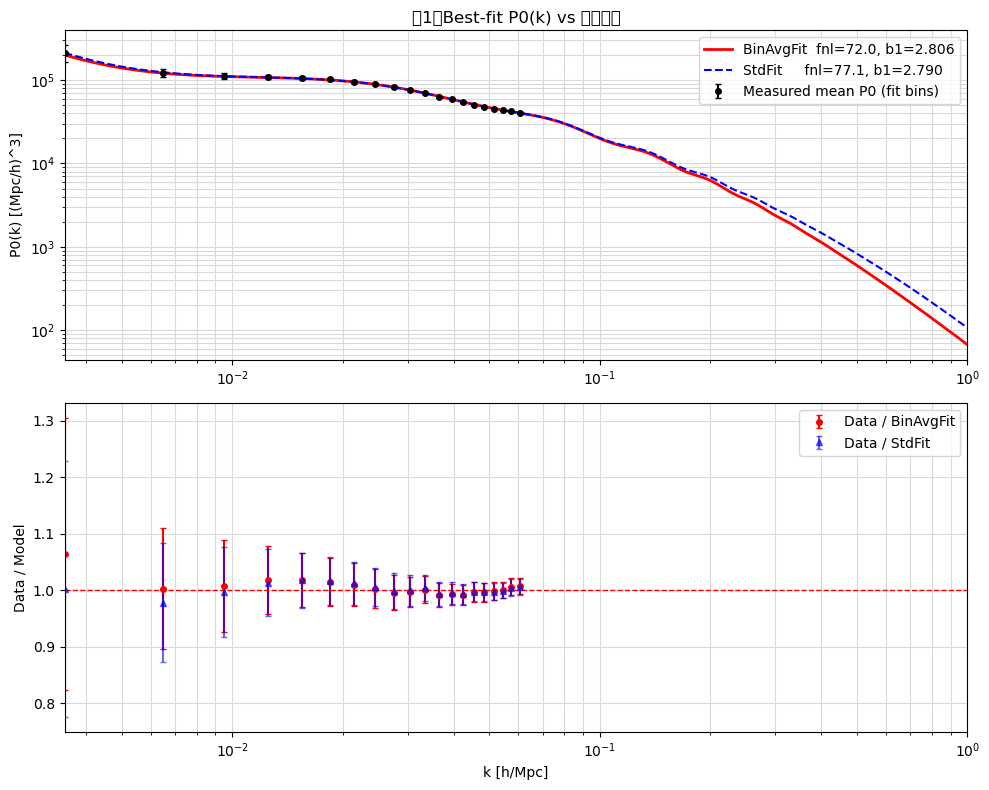

In [7]:
# ============================================================
# Cell 7：图1 — P0(k) 均值 vs BinAvgFit / 标准拟合曲线
# ============================================================

# 在宽 k 网格上评估两套 best-fit 曲线（供画图用）
k_plot    = np.geomspace(k_values.min(), 1.0, 400)
tmpl_plot = FixedPowerSpectrumTemplate(z=UNIT_Z, fiducial=cosmo_unit)

def eval_pk_on_grid(k_grid, params):
    """
    在指定 k 网格上评估 desilike 的 PNG 理论功率谱 P0(k)。

    参数
    ----
    k_grid : ndarray  k 网格 (h/Mpc)。
    params : dict     参数字典（fnl_loc, b1, sigmas, p, sn0）。

    返回
    ----
    ndarray  P0(k) 值。
    """
    th = PNGTracerPowerSpectrumMultipoles(k=k_grid, template=tmpl_plot, mode='b-p')
    th.init.params['p'].update(fixed=True, value=FIXED_P)
    th.init.params['sn0'].update(fixed=True, value=FIXED_SN0)
    th.init.params['sigmas'].update(fixed=False, value=float(params.get('sigmas', 0.0)))
    th(**params)
    return np.array(th.power[0], dtype=float)

p0_model_binavg = eval_pk_on_grid(k_plot, bestfit_binavg)
p0_model_std    = eval_pk_on_grid(k_plot, bestfit_std)

# 画图 1
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.errorbar(k_values, p0_mean, yerr=pk_data['std'],
             fmt='o', ms=4, capsize=2, color='black',
             label='Measured mean P0 (fit bins)')
ax1.loglog(k_plot, p0_model_binavg, 'r-', lw=2,
           label=f'BinAvgFit  fnl={bestfit_binavg["fnl_loc"]:.1f}, b1={bestfit_binavg["b1"]:.3f}')
ax1.loglog(k_plot, p0_model_std, 'b--', lw=1.5,
           label=f'StdFit     fnl={float(bestfit_std["fnl_loc"]):.1f}, b1={float(bestfit_std["b1"]):.3f}')
ax1.set_xlim(k_values.min(), 1.0)
ax1.grid(True, which='both', ls='-', color='0.85')
ax1.set_ylabel('P0(k) [(Mpc/h)^3]')
ax1.set_title('图1：Best-fit P0(k) vs 测量均值')
ax1.legend()

# 下图：data/model 比值（只画在拟合区间内）
model_at_data_binavg = eval_pk_on_grid(k_values, bestfit_binavg)
model_at_data_std    = eval_pk_on_grid(k_values, bestfit_std)

ax2.errorbar(k_values, p0_mean / model_at_data_binavg,
             yerr=pk_data['std'] / np.abs(model_at_data_binavg),
             fmt='ro', ms=4, capsize=2, label='Data / BinAvgFit')
ax2.errorbar(k_values, p0_mean / model_at_data_std,
             yerr=pk_data['std'] / np.abs(model_at_data_std),
             fmt='b^', ms=4, capsize=2, alpha=0.6, label='Data / StdFit')
ax2.axhline(1.0, color='red', ls='--', lw=1)
ax2.set_xscale('log')
ax2.set_xlim(k_values.min(), 1.0)
ax2.grid(True, which='both', ls='-', color='0.85')
ax2.set_xlabel('k [h/Mpc]')
ax2.set_ylabel('Data / Model')
ax2.legend()

plt.tight_layout(); plt.show()

In [8]:
# ============================================================
# Cell 8：FullDiscrete 离散求和建模 ξ0(r)（k-rebinning 加速版）
#
# 公式（任务书 §9）：
#   ξ0(r) = (1/V) Σ_{q, k_q ≤ kmax} g_q · P_model(k_q) · j0(k_q r)
#
# 加速方案（任务书 §11）：
#   把壳层按 k 值聚合到等间距 bin（dk = 0.1 * kf），
#   用 bin 内 g_q 加权平均的 k_eff 代替所有壳层。
#   预计算 G_bin 和 k_eff 后缓存（只依赖 L, kmax），
#   每次更换 P_model 只需 ~0.08s（3Gpc）/ ~0.01s（1Gpc）。
#   精度：mean|Δξ/ξ| < 0.2%，vs data 指标差异 < 0.003。
# ============================================================

def j0(x):
    """球贝塞尔函数 j0(x) = sin(x)/x，x=0 处极限为 1。"""
    x   = np.asarray(x, dtype=float)
    out = np.ones_like(x)
    nz  = x != 0
    out[nz] = np.sin(x[nz]) / x[nz]
    return out


def gq_fft(qmax, nmax):
    """
    用 FFT 卷积精确计算壳层简并度 g_q。

    算法：a[0]=1, a[n²]=2 (n≥1)；g = round(IFFT(FFT(a)³))。

    参数
    ----
    qmax : int  最大 q 值。
    nmax : int  模索引最大值，通常取 floor(kmax/kf)。

    返回
    ----
    gq : ndarray (qmax+1,) int64
    """
    a    = np.zeros(qmax + 1, dtype=np.float32)
    a[0] = 1.0
    sq   = np.arange(1, nmax + 1, dtype=np.int64) ** 2
    a[sq[sq <= qmax]] = 2.0
    nfft = next_fast_len(3 * qmax + 1)
    fa   = rfft(a, n=nfft)
    return np.rint(irfft(fa * fa * fa, n=nfft)[:qmax + 1]).astype(np.int64)


def precompute_rebin_cache(gq, kf, kmax, dk_factor=0.1):
    """
    预计算 k-rebinning 缓存（一次性，只依赖盒长 L 和 kmax）。

    把所有非零壳层按 k 值放入等间距 bin，计算每个 bin 的：
    - G_nz: sum(g_q)，即 bin 内的总模式数
    - k_eff: g_q 加权平均的 k 值

    参数
    ----
    gq        : ndarray  壳层简并度数组（gq_fft 的输出）。
    kf        : float    基模 2π/L (h/Mpc)。
    kmax      : float    离散求和截断 (h/Mpc)。
    dk_factor : float    bin 宽 = dk_factor * kf，默认 0.1（精度 ~0.2%）。

    返回
    ----
    G_nz  : ndarray  每个非空 bin 的 sum(g_q)。
    k_eff : ndarray  每个非空 bin 的 g_q 加权平均 k。
    """
    qnz     = np.nonzero(gq[1:])[0] + 1
    kv      = kf * np.sqrt(qnz.astype(np.float64))
    g       = gq[qnz].astype(np.float64)
    dk      = dk_factor * kf
    n_bins  = int(np.ceil(kmax / dk)) + 1
    bin_idx = np.clip((kv / dk).astype(np.int64), 0, n_bins - 1)
    G_bin   = np.bincount(bin_idx, weights=g,      minlength=n_bins)
    Gk_bin  = np.bincount(bin_idx, weights=g * kv, minlength=n_bins)
    nz      = G_bin > 0
    G_nz    = G_bin[nz].astype(np.float64)
    k_eff   = Gk_bin[nz] / G_nz
    return G_nz, k_eff


def fast_discrete_xi0(s, G_nz, k_eff, V, kd, pd):
    """
    k-rebinning 加速版离散求和 ξ0(r)。

    用预计算的 G_nz 和 k_eff，只需对 ~N_bin 个点做 interp + sin + matmul。

    参数
    ----
    s     : ndarray  r 网格 (Mpc/h)。
    G_nz  : ndarray  预计算的 bin 模式数（precompute_rebin_cache 输出）。
    k_eff : ndarray  预计算的 bin 加权平均 k（precompute_rebin_cache 输出）。
    V     : float    体积 L^3。
    kd    : ndarray  密集 k 网格（用于插值 P_model）。
    pd    : ndarray  P_model(kd) 值。

    返回
    ----
    xi0 : ndarray (len(s),)  ξ0(r)。
    """
    W   = G_nz * np.interp(k_eff, kd, pd)
    arg = np.outer(k_eff, s)
    J   = np.ones_like(arg)
    m   = arg != 0
    J[m] = np.sin(arg[m]) / arg[m]
    return (W @ J) / V


# ---- 计算 g_q ----
qmax_fd = int((KMAX_DISCRETE / K_FUND) ** 2)
nmax_fd = int(KMAX_DISCRETE / K_FUND)
print(f'计算 g_q（FFT 卷积，qmax={qmax_fd}）...')
t0 = time.time()
gq_fd = gq_fft(qmax_fd, nmax_fd)
n_shells = np.count_nonzero(gq_fd[1:])
print(f'  完成，耗时 {time.time()-t0:.1f}s，非零壳层数 = {n_shells}')

# ---- 预计算 k-rebinning 缓存 ----
DK_FACTOR = 0.1    # bin 宽 = 0.1 * kf
print(f'\n预计算 k-rebinning 缓存（dk = {DK_FACTOR} * kf）...')
t0 = time.time()
G_nz, k_eff = precompute_rebin_cache(gq_fd, K_FUND, KMAX_DISCRETE, dk_factor=DK_FACTOR)
print(f'  完成，耗时 {time.time()-t0:.2f}s，{len(G_nz)} 个 bin（压缩比 {n_shells/len(G_nz):.0f}x）')

# ---- 评估 P_model(k) ----
kd = np.geomspace(K_FUND * 0.5, KMAX_DISCRETE * 1.1, N_DENSE)
print('\n评估 BinAvgFit P_model(k) ...')
pd_binavg = eval_pk_on_grid(kd, bestfit_binavg)
print('评估 StdFit P_model(k) ...')
pd_std    = eval_pk_on_grid(kd, bestfit_std)
print('P_model(k) 评估完成。')

In [9]:
# ============================================================
# Cell 9：读取 2PCF 观测数据
# ============================================================

print('读取 2PCF 数据...')
s_data, xi_mean, xi_std = load_pcf_ensemble(
    PCF_DIR, PCF_GLOB, REALIZATION_MIN, REALIZATION_MAX
)
print(f'  r 范围 = [{s_data.min():.1f}, {s_data.max():.1f}] Mpc/h')

读取 2PCF 数据...
  r 范围 = [56.0, 380.0] Mpc/h


In [10]:
# ============================================================
# Cell 10：加速版离散求和 + 对比画图
# ============================================================

print('加速版 FullDiscrete（BinAvgFit 参数）...')
t0 = time.time()
xi0_binavg = fast_discrete_xi0(s_data, G_nz, k_eff, VOL, kd, pd_binavg)
t_fast = time.time() - t0
print(f'  完成，耗时 {t_fast:.4f}s')

print('加速版 FullDiscrete（StdFit 参数）...')
t0 = time.time()
xi0_std = fast_discrete_xi0(s_data, G_nz, k_eff, VOL, kd, pd_std)
t_fast2 = time.time() - t0
print(f'  完成，耗时 {t_fast2:.4f}s')

# r^2 * ξ0
r2_data    = s_data**2 * xi_mean
r2_err     = s_data**2 * xi_std
r2_binavg  = s_data**2 * xi0_binavg
r2_std_fd  = s_data**2 * xi0_std

ds_binavg = (r2_data - r2_binavg) / r2_err
ds_std_fd = (r2_data - r2_std_fd) / r2_err

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9))

ax1.errorbar(s_data, r2_data, yerr=r2_err,
             fmt='ko', ms=4, capsize=2, label='Measured mean', zorder=10)
ax1.plot(s_data, r2_binavg, 'r-', lw=2.5,
         label=f'BinAvgFit + FastDiscrete  fnl={bestfit_binavg["fnl_loc"]:.1f}')
ax1.plot(s_data, r2_std_fd, 'b--', lw=1.8,
         label=f'StdFit + FastDiscrete  fnl={float(bestfit_std["fnl_loc"]):.1f}')
ax1.set_ylabel(r'$r^2\xi_0(r)$', fontsize=13)
ax1.set_title(r'$r^2\xi_0(r)$ — BinAvgFit + FastDiscrete (k-rebinning)')
ax1.legend(fontsize=10); ax1.grid(True, ls='--', alpha=0.35)

ax2.axhline(0.0, color='k', lw=1.0)
for lv in [1.0, -1.0]:
    ax2.axhline(lv, color='gray', ls=':', lw=0.8)
for lv in [2.0, -2.0]:
    ax2.axhline(lv, color='orange', ls=':', lw=0.8)
ax2.plot(s_data, ds_binavg, 'ro-', ms=4, lw=1.5, label='BinAvgFit + FastDiscrete')
ax2.plot(s_data, ds_std_fd, 'b^--', ms=4, lw=1.2, alpha=0.75, label='StdFit + FastDiscrete')
ax2.set_xlabel(r'$r\,[\mathrm{Mpc}/h]$', fontsize=13)
ax2.set_ylabel(r'$(\mathrm{Data}-\mathrm{Model})/\sigma$', fontsize=12)
ax2.set_title('Residuals (Data-Model)/σ')
ax2.set_ylim(-3, 3)
ax2.legend(fontsize=10); ax2.grid(True, ls='--', alpha=0.35)

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# Cell 11：指标输出与 best-fit 参数汇总（FastDiscrete k-rebinning 版）
# ============================================================

def print_metrics(r2_data, r2_err, r2_model, label):
    """
    计算并打印 mean(|Δ/σ|) 和 mean(Δ/σ)。

    参数
    ----
    r2_data, r2_err, r2_model : ndarray  r^2·ξ0 的观测值、误差、模型值。
    label : str  方法名，用于打印。

    返回
    ----
    (mean_abs, mean_signed) : (float, float)
    """
    ds       = (r2_data - r2_model) / r2_err
    mean_abs = float(np.nanmean(np.abs(ds)))
    mean_sig = float(np.nanmean(ds))
    print(f'  {label:35s}  mean|Δ/σ| = {mean_abs:.4f},  mean(Δ/σ) = {mean_sig:+.4f}')
    return mean_abs, mean_sig


print('===== 建模指标（全 r 范围） =====')
print_metrics(r2_data, r2_err, r2_binavg, 'BinAvgFit + FullDiscrete')
print_metrics(r2_data, r2_err, r2_std_fd, 'StdFit    + FullDiscrete')

mask_large = s_data >= 200.0
print(f'\n===== 大尺度指标（r ≥ 200 Mpc/h，{mask_large.sum()} 个点） =====')
print_metrics(r2_data[mask_large], r2_err[mask_large],
              r2_binavg[mask_large], 'BinAvgFit + FullDiscrete')
print_metrics(r2_data[mask_large], r2_err[mask_large],
              r2_std_fd[mask_large], 'StdFit    + FullDiscrete')

print('\n===== BinAvgFit best-fit 参数汇总 =====')
print(f'  fnl_loc = {bestfit_binavg["fnl_loc"]:.4f}')
print(f'  b1      = {bestfit_binavg["b1"]:.6f}')
print(f'  sigmas  = {bestfit_binavg["sigmas"]:.6f}')
print(f'  p   (固定) = {FIXED_P}')
print(f'  sn0 (固定) = {FIXED_SN0}')